## 1. Setup and Imports

In [1]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q xgboost textstat spacy nltk
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q gensim transformers datasets peft accelerate
!pip install -q tqdm

# Download spaCy model
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 115.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
import os
import re  # ADDED: for text preprocessing
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# NLP libraries
import spacy
import textstat
import nltk
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score
import xgboost as xgb

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# GloVe Embeddings
import gensim.downloader as api

# Transformers (for Tier C only)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset as HFDataset

# Progress bars
from tqdm.auto import tqdm

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("✓ All imports successful!")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ All imports successful!
✓ PyTorch version: 2.9.0+cu126
✓ CUDA available: True


## 2. Data Loading and Exploration

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# PROJECT_PATH = '/content/drive/MyDrive/Precog_NLP_Task_FIXED'

# MODEL_DIR = "/content/drive/MyDrive/Precog_NLP_Task_FIXED/models"

# os.makedirs(MODEL_DIR, exist_ok=True)

# print(f"Models will be saved to: {MODEL_DIR}")

# Load the dataset
# df = pd.read_csv(os.path.join(PROJECT_PATH, 'complete_dataset.csv'))
df = pd.read_csv('complete_dataset.csv')


print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nClass Distribution:")
print(df['class'].value_counts())
print("\nFirst few rows:")
df.head()

Dataset Shape: (2926, 6)

Column Names:
['text', 'word_count', 'class', 'author', 'topic', 'sample_id']

Class Distribution:
class
human          1926
ai_mimicked     500
ai_neutral      500
Name: count, dtype: int64

First few rows:


,text,word_count,class,author,topic,sample_id
0,Every disposition of the ground was good; and ...,103,human,Austen,original_literature,0
1,I thought he would be more glad if I came upon...,157,human,Dickens,original_literature,1
2,"I trust, and I almost believe, that the circum...",123,human,Dickens,original_literature,2
3,"The art of self-deception is, perhaps, most sk...",134,ai_mimicked,Austen_mimicked,Self-Deception,3
4,"It would be an interesting, and certainly a ve...",168,human,Austen,original_literature,4


## 3. Feature Engineering (The Bridge from Task 1)

We'll calculate the following features identified as statistically significant in Task 1:
1. **Lexical Richness**: Type-Token Ratio (TTR)
2. **Syntactic Complexity**: Average Dependency Tree Depth, Adjective-to-Noun Ratio
3. **Readability**: Flesch-Kincaid Grade Level
4. **Punctuation Density**: Semicolon and Comma density per 100 words

In [6]:
# RESULTS_PATH = PROJECT_PATH+'/task1_results/task1_results.csv'

try:
    # Load the individual metrics for all 1500 samples
    df = pd.read_csv('task1_results.csv')

    # Standardize column names for Tier A
    rename_map = {
        'TreeDepth': 'tree_depth',
        'AdjToNounRatio': 'adj_noun_ratio',
        'FK_Grade': 'flesch_kincaid',
        'Semicolons': 'semicolon_density',
        'Commas': 'comma_density',
        'STTR_mean': 'ttr',
        'sttr': 'ttr'
    }
    df = df.rename(columns=rename_map)

    feature_cols = ['ttr', 'tree_depth', 'adj_noun_ratio', 'flesch_kincaid', 'semicolon_density', 'comma_density']
    print(f"✓ Successfully merged {len(df)} samples with numerical features.")

except Exception as e:
    print(f"Error merging data: {e}.")

✓ Successfully merged 2926 samples with numerical features.


## 4. Data Preparation

In [7]:
# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['class'])

# Validate that we have all 3 classes (0, 1, 2)
print("Label Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Prepare arrays
X_features = df[feature_cols].values # These now exist thanks to the merge above
X_text = df['sample'].values
y = df['label'].values

# Stratified Split (Maintaining class balance)
X_feat_train, X_feat_temp, X_text_train, X_text_temp, y_train, y_temp = train_test_split(
    X_features, X_text, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

X_feat_val, X_feat_test, X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_feat_temp, X_text_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"\nDataset Splits:")
print(f"  Train: {len(X_feat_train)} samples ({len(X_feat_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(X_feat_val)} samples ({len(X_feat_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(X_feat_test)} samples ({len(X_feat_test)/len(df)*100:.1f}%)")

Label Mapping: {'ai_mimicked': np.int64(0), 'ai_neutral': np.int64(1), 'human': np.int64(2)}

Dataset Splits:
  Train: 2048 samples (70.0%)
  Val:   439 samples (15.0%)
  Test:  439 samples (15.0%)


---
## 5. TIER A: The Statistician (XGBoost)

Using only the numerical features extracted from Task 1.

In [8]:
# Scale features
scaler = StandardScaler()
X_feat_train_scaled = scaler.fit_transform(X_feat_train)
X_feat_val_scaled = scaler.transform(X_feat_val)
X_feat_test_scaled = scaler.transform(X_feat_test)

print("✓ Features scaled using StandardScaler")

✓ Features scaled using StandardScaler


In [10]:
# Train XGBoost Classifier
print("Training XGBoost Classifier...\n")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    verbose=False
)

xgb_model.fit(
    X_feat_train_scaled, y_train,
    eval_set=[(X_feat_val_scaled, y_val)],
    verbose=False
)
import joblib

joblib.dump(xgb_model, "tierA_xgb_tertiary.pkl")
print("✓ Tier A XGB model saved")

# Predictions
y_pred_xgb = xgb_model.predict(X_feat_test_scaled)

# Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
prec_xgb = precision_score(y_test, y_pred_xgb, average='macro')

print("✓ XGBoost Training Complete!\n")
print("Performance Metrics:")
print(f"  Accuracy:  {acc_xgb:.4f}")
print(f"  F1-Score:  {f1_xgb:.4f}")
print(f"  Precision: {prec_xgb:.4f}")

Training XGBoost Classifier...

✓ Tier A XGB model saved
✓ XGBoost Training Complete!

Performance Metrics:
  Accuracy:  0.9021
  F1-Score:  0.8696
  Precision: 0.8829


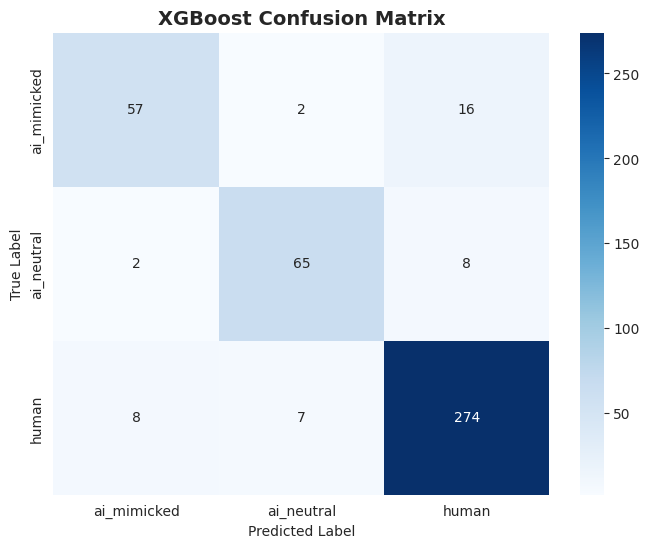


Classification Report:
              precision    recall  f1-score   support

 ai_mimicked       0.85      0.76      0.80        75
  ai_neutral       0.88      0.87      0.87        75
       human       0.92      0.95      0.93       289

    accuracy                           0.90       439
   macro avg       0.88      0.86      0.87       439
weighted avg       0.90      0.90      0.90       439



In [11]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax)
ax.set_title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))

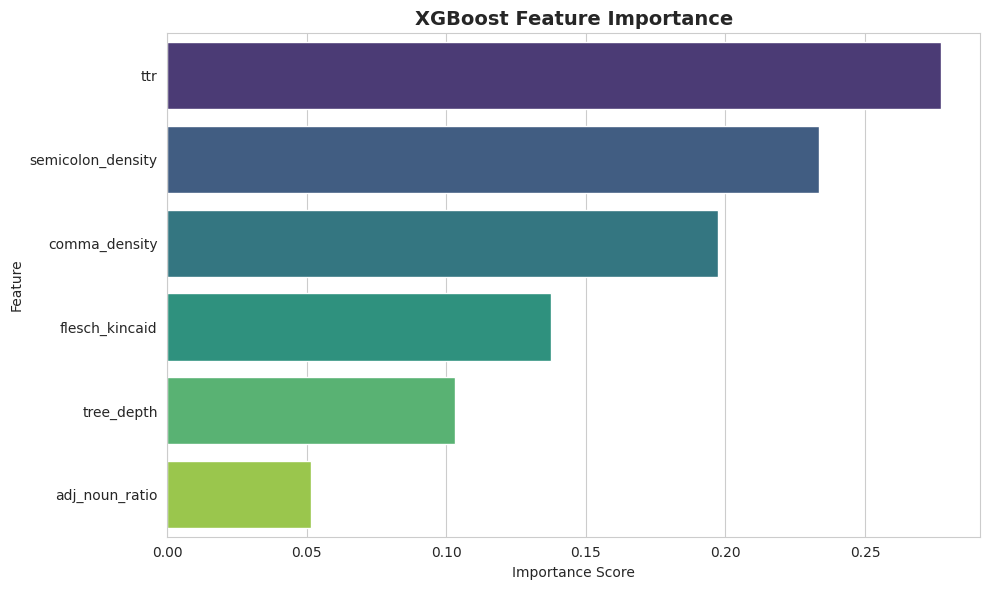


Feature Importance Ranking:
          feature  importance
              ttr    0.277355
semicolon_density    0.233449
    comma_density    0.197236
   flesch_kincaid    0.137587
       tree_depth    0.102949
   adj_noun_ratio    0.051424


In [12]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

---
## 6. TIER B: The Semanticist (Feedforward Neural Network)

Using **GloVe** (Global Vectors for Word Representation) embeddings.

**Approach:**
- Load pre-trained GloVe word vectors (100-dimensional)
- Average word embeddings to create sentence representations
- Feed into a Feedforward Neural Network

**Why GloVe:**
- Task specification requires GloVe or FastText
- Static word embeddings (context-free)
- Contrasts with Tier C (contextualized transformer embeddings)

In [13]:
# TIER B: GloVe Embeddings (Task-Compliant Implementation)

# Step 1: Load GloVe embeddings
print("Loading GloVe embeddings (glove-wiki-gigaword-100)...")
print("This may take 1-2 minutes on first run (downloads ~130MB)...\n")

try:
    glove_model = api.load("glove-wiki-gigaword-100")
    print("✓ GloVe model loaded successfully!")
    print(f"✓ Vocabulary size: {len(glove_model):,} words")
    print(f"✓ Embedding dimension: 100\n")
except Exception as e:
    print(f"Error loading GloVe: {e}")
    print("Trying to download again...")
    glove_model = api.load("glove-wiki-gigaword-100")

# Step 2: Define text preprocessing and embedding function
def preprocess_text(text):
    """Clean and tokenize text for GloVe embedding."""
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation but keep spaces
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    return words

def get_glove_embedding(text, model, embedding_dim=100):
    """
    Generate sentence embedding by averaging GloVe word vectors.

    Args:
        text: Input text string
        model: Loaded GloVe model
        embedding_dim: Dimension of embeddings (100 for glove-wiki-gigaword-100)

    Returns:
        numpy array of shape (embedding_dim,)
    """
    # Preprocess text
    words = preprocess_text(text)

    # Get embeddings for words in vocabulary
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])

    # Average word vectors (or return zero vector if no words found)
    if len(word_vectors) > 0:
        sentence_embedding = np.mean(word_vectors, axis=0)
    else:
        # Return zero vector if no words in vocabulary
        sentence_embedding = np.zeros(embedding_dim)

    return sentence_embedding

# Step 3: Generate embeddings for all splits
print("Generating GloVe embeddings for train set...")
X_emb_train = np.array([
    get_glove_embedding(text, glove_model)
    for text in X_text_train.tolist()
])
print(f"✓ Train embeddings: {X_emb_train.shape}")

print("\nGenerating GloVe embeddings for validation set...")
X_emb_val = np.array([
    get_glove_embedding(text, glove_model)
    for text in X_text_val.tolist()
])
print(f"✓ Validation embeddings: {X_emb_val.shape}")

print("\nGenerating GloVe embeddings for test set...")
X_emb_test = np.array([
    get_glove_embedding(text, glove_model)
    for text in X_text_test.tolist()
])
print(f"✓ Test embeddings: {X_emb_test.shape}")

# Step 4: Embedding statistics
print(f"\n" + "="*60)
print("EMBEDDING STATISTICS")
print("="*60)
print(f"Embedding dimension: {X_emb_train.shape[1]}")
print(f"Train samples: {X_emb_train.shape[0]}")
print(f"Validation samples: {X_emb_val.shape[0]}")
print(f"Test samples: {X_emb_test.shape[0]}")

# Check coverage (how many samples have at least one word in vocabulary)
def check_coverage(X_text, model):
    """Check what percentage of texts have at least one word in vocabulary."""
    covered = 0
    for text in X_text.tolist():
        words = preprocess_text(text)
        if any(word in model for word in words):
            covered += 1
    return (covered / len(X_text)) * 100

train_coverage = check_coverage(X_text_train, glove_model)
print(f"\nVocabulary coverage (train): {train_coverage:.2f}%")
print("="*60)
print("\n✓ GloVe embedding generation complete!\n")

Loading GloVe embeddings (glove-wiki-gigaword-100)...
This may take 1-2 minutes on first run (downloads ~130MB)...

[==================================================] 100.0% 128.1/128.1MB downloaded
✓ GloVe model loaded successfully!
✓ Vocabulary size: 400,000 words
✓ Embedding dimension: 100

Generating GloVe embeddings for train set...
✓ Train embeddings: (2048, 100)

Generating GloVe embeddings for validation set...
✓ Validation embeddings: (439, 100)

Generating GloVe embeddings for test set...
✓ Test embeddings: (439, 100)

EMBEDDING STATISTICS
Embedding dimension: 100
Train samples: 2048
Validation samples: 439
Test samples: 439

Vocabulary coverage (train): 100.00%

✓ GloVe embedding generation complete!



In [14]:
# Define PyTorch Dataset
class TextDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Create datasets
train_dataset = TextDataset(X_emb_train, y_train)
val_dataset = TextDataset(X_emb_val, y_val)
test_dataset = TextDataset(X_emb_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("✓ PyTorch datasets and dataloaders created!")

✓ PyTorch datasets and dataloaders created!


In [15]:
# Define Feedforward Neural Network
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim=100, hidden_dims=[128, 64], num_classes=3, dropout=0.5):  # CHANGED: input_dim=100
        super(FeedForwardNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ffnn_model = FeedForwardNN(input_dim=100).to(device)  # CHANGED: explicitly set input_dim=100
print(f"\nModel Architecture:")
print(ffnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")

Using device: cuda

Model Architecture:
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total parameters: 21,763


In [17]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ffnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training loop
num_epochs = 30
best_val_loss = float('inf')
patience = 3
patience_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\nTraining Feedforward Neural Network...\n")

for epoch in range(num_epochs):
    # Training phase
    ffnn_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for embeddings, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        embeddings, labels = embeddings.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ffnn_model(embeddings)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    ffnn_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for embeddings, labels in val_loader:
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = ffnn_model(embeddings)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(ffnn_model.state_dict(), 'best_ffnn_model.pt')
        torch.save(ffnn_model.state_dict(), "tierB_embedding_nn_tertiary.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Save Tier B neural network
torch.save(ffnn_model, "tierB_full_model_tertiary.pt")

print("✓ Tier B embedding NN saved")

print("\n✓ Training complete!")


Training Feedforward Neural Network...



Epoch 1/30 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/30 - Train Loss: 0.1548, Train Acc: 0.9595 | Val Loss: 0.0414, Val Acc: 1.0000


Epoch 2/30 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 2/30 - Train Loss: 0.1034, Train Acc: 0.9751 | Val Loss: 0.0204, Val Acc: 1.0000


...

Epoch 9/30 - Train Loss: 0.0422, Train Acc: 0.9883 | Val Loss: 0.0068, Val Acc: 1.0000


Epoch 10/30 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 10/30 - Train Loss: 0.0466, Train Acc: 0.9824 | Val Loss: 0.0110, Val Acc: 0.9977


Epoch 11/30 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 11/30 - Train Loss: 0.0406, Train Acc: 0.9849 | Val Loss: 0.0086, Val Acc: 0.9977

Early stopping triggered at epoch 11
✓ Tier B embedding NN saved

✓ Training complete!


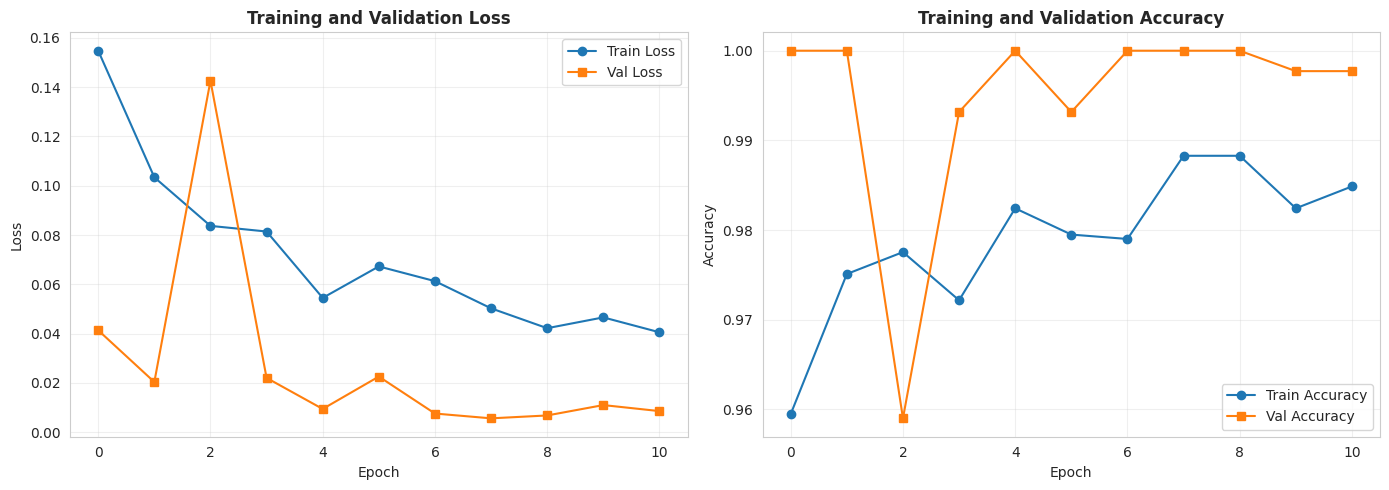

In [18]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_title('Training and Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label='Train Accuracy', marker='o')
axes[1].plot(val_accs, label='Val Accuracy', marker='s')
axes[1].set_title('Training and Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Load best model and evaluate on test set
ffnn_model.load_state_dict(torch.load('best_ffnn_model.pt'))
ffnn_model.eval()

y_pred_ffnn = []

with torch.no_grad():
    for embeddings, _ in test_loader:
        embeddings = embeddings.to(device)
        outputs = ffnn_model(embeddings)
        _, predicted = torch.max(outputs.data, 1)
        y_pred_ffnn.extend(predicted.cpu().numpy())

y_pred_ffnn = np.array(y_pred_ffnn)

# Metrics
acc_ffnn = accuracy_score(y_test, y_pred_ffnn)
f1_ffnn = f1_score(y_test, y_pred_ffnn, average='macro')
prec_ffnn = precision_score(y_test, y_pred_ffnn, average='macro')

print("Performance Metrics on Test Set:")
print(f"  Accuracy:  {acc_ffnn:.4f}")
print(f"  F1-Score:  {f1_ffnn:.4f}")
print(f"  Precision: {prec_ffnn:.4f}")

Performance Metrics on Test Set:
  Accuracy:  0.9977
  F1-Score:  0.9956
  Precision: 0.9956


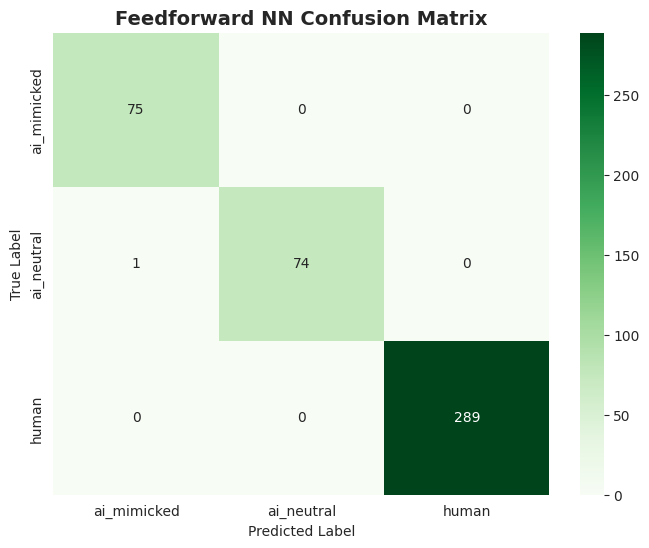


Classification Report:
              precision    recall  f1-score   support

 ai_mimicked       0.99      1.00      0.99        75
  ai_neutral       1.00      0.99      0.99        75
       human       1.00      1.00      1.00       289

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439



In [20]:
# Confusion Matrix
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax)
ax.set_title('Feedforward NN Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=label_encoder.classes_))

---
## 7. TIER C: The Transformer (Fine-tuned DistilBERT with LoRA)

Using Parameter-Efficient Fine-Tuning (PEFT) with LoRA adapters.

In [21]:
# Load tokenizer and model
MODEL_NAME = "distilbert-base-uncased"
print(f"Loading {MODEL_NAME}...\n")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: label_encoder.classes_[0], 1: label_encoder.classes_[1], 2: label_encoder.classes_[2]},
    label2id={label_encoder.classes_[0]: 0, label_encoder.classes_[1]: 1, label_encoder.classes_[2]: 2}
)

print("✓ Base model loaded!")
print(f"Total parameters: {sum(p.numel() for p in base_model.parameters()):,}")

Loading distilbert-base-uncased...



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded!
Total parameters: 66,955,779


In [22]:
# --- REVISED LORA CONFIGURATION ---
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4, # Increased rank for better stylistic capturing
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q_lin"], # Targeted DistilBERT attention layers
    bias="none"
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.print_trainable_parameters()

print(f"\nReduction: {sum(p.numel() for p in lora_model.parameters() if p.requires_grad) / sum(p.numel() for p in base_model.parameters()) * 100:.2f}% trainable parameters")

trainable params: 629,763 || all params: 67,585,542 || trainable%: 0.9318

Reduction: 0.93% trainable parameters


In [23]:
# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )

# Create HuggingFace datasets
train_df = pd.DataFrame({'text': X_text_train, 'label': y_train})
val_df = pd.DataFrame({'text': X_text_val, 'label': y_val})
test_df = pd.DataFrame({'text': X_text_test, 'label': y_test})

hf_train_dataset = HFDataset.from_pandas(train_df)
hf_val_dataset = HFDataset.from_pandas(val_df)
hf_test_dataset = HFDataset.from_pandas(test_df)

# Tokenize
print("Tokenizing datasets...")
hf_train_dataset = hf_train_dataset.map(tokenize_function, batched=True)
hf_val_dataset = hf_val_dataset.map(tokenize_function, batched=True)
hf_test_dataset = hf_test_dataset.map(tokenize_function, batched=True)

print("✓ Tokenization complete!")

Tokenizing datasets...


Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

Map:   0%|          | 0/439 [00:00<?, ? examples/s]

Map:   0%|          | 0/439 [00:00<?, ? examples/s]

✓ Tokenization complete!


In [24]:

# Define training arguments
training_args = TrainingArguments(
    output_dir="./distilbert_lora_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.05,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,
    logging_steps=10,
    warmup_steps=100,
    fp16=torch.cuda.is_available(),
    seed=RANDOM_SEED,
    report_to="none"
)

# Define compute metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='macro')
    }

print("✓ Training configuration set!")

✓ Training configuration set!


In [26]:
# Initialize Trainer
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=hf_train_dataset,
    eval_dataset=hf_val_dataset,
    # tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\nStarting fine-tuning...\n")
trainer.train()
print("\n✓ Fine-tuning complete!")

# Save transformer model
trainer.save_model("tierC_transformer_tertiary")

tokenizer.save_pretrained("tierC_transformer_tertiary")

print("✓ Tier C transformer saved")


Starting fine-tuning...



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision
1,0.013235,0.027362,0.993166,0.991725,0.987179
2,0.008789,0.010649,0.993166,0.991644,0.990071
3,0.006152,0.009711,0.995444,0.994402,0.994402



✓ Fine-tuning complete!
✓ Tier C transformer saved


In [27]:
# Evaluate on test set
print("\nEvaluating on test set...")
test_results = trainer.predict(hf_test_dataset)

y_pred_transformer = np.argmax(test_results.predictions, axis=1)

# Metrics
acc_transformer = accuracy_score(y_test, y_pred_transformer)
f1_transformer = f1_score(y_test, y_pred_transformer, average='macro')
prec_transformer = precision_score(y_test, y_pred_transformer, average='macro')

print("\nPerformance Metrics on Test Set:")
print(f"  Accuracy:  {acc_transformer:.4f}")
print(f"  F1-Score:  {f1_transformer:.4f}")
print(f"  Precision: {prec_transformer:.4f}")


Evaluating on test set...



Performance Metrics on Test Set:
  Accuracy:  1.0000
  F1-Score:  1.0000
  Precision: 1.0000


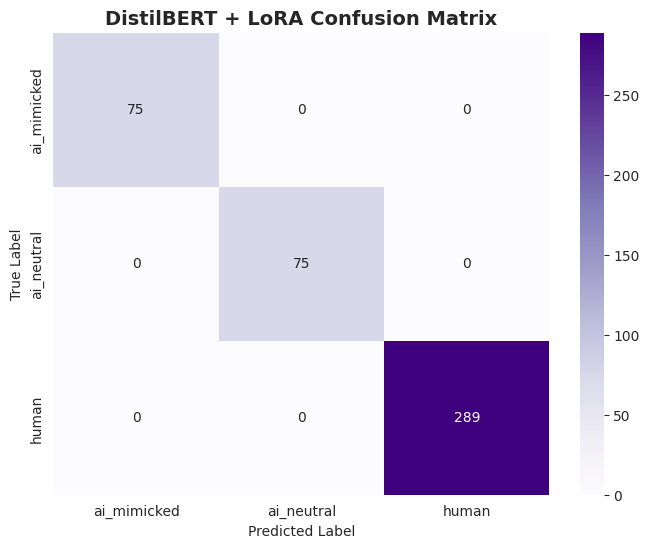


Classification Report:
              precision    recall  f1-score   support

 ai_mimicked       1.00      1.00      1.00        75
  ai_neutral       1.00      1.00      1.00        75
       human       1.00      1.00      1.00       289

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439



In [28]:
# Confusion Matrix
cm_transformer = confusion_matrix(y_test, y_pred_transformer)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax)
ax.set_title('DistilBERT + LoRA Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_transformer, target_names=label_encoder.classes_))

---
## 8. Comparative Evaluation

In [29]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Tier A: XGBoost', 'Tier B: FeedForward NN', 'Tier C: DistilBERT + LoRA'],
    'Accuracy': [acc_xgb, acc_ffnn, acc_transformer],
    'F1-Score (Macro)': [f1_xgb, f1_ffnn, f1_transformer],
    'Precision (Macro)': [prec_xgb, prec_ffnn, prec_transformer]
}).round(4)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


FINAL MODEL COMPARISON
                    Model  Accuracy  F1-Score (Macro)  Precision (Macro)
          Tier A: XGBoost    0.9021            0.8696             0.8829
   Tier B: FeedForward NN    0.9977            0.9956             0.9956
Tier C: DistilBERT + LoRA    1.0000            1.0000             1.0000


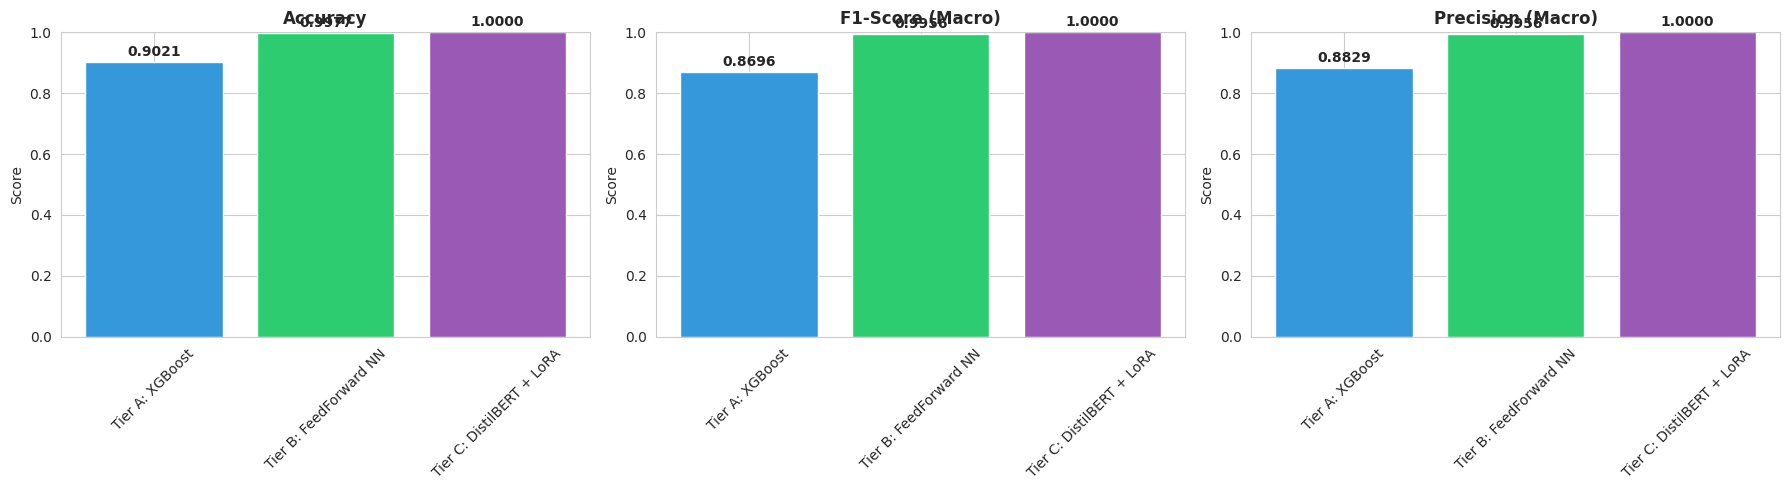

In [30]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Accuracy', 'F1-Score (Macro)', 'Precision (Macro)']
colors = ['#3498db', '#2ecc71', '#9b59b6']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=colors)
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. Error Analysis

Identifying samples where Tier A succeeded but Tier C failed, and vice-versa.

In [31]:
# Create predictions dataframe
error_analysis_df = pd.DataFrame({
    'text': X_text_test,
    'true_label': y_test,
    'true_class': [label_encoder.classes_[i] for i in y_test],
    'xgb_pred': y_pred_xgb,
    'transformer_pred': y_pred_transformer,
    'xgb_correct': y_pred_xgb == y_test,
    'transformer_correct': y_pred_transformer == y_test
})

# XGBoost correct, Transformer wrong
xgb_wins = error_analysis_df[
    (error_analysis_df['xgb_correct'] == True) &
    (error_analysis_df['transformer_correct'] == False)
]

# Transformer correct, XGBoost wrong
transformer_wins = error_analysis_df[
    (error_analysis_df['xgb_correct'] == False) &
    (error_analysis_df['transformer_correct'] == True)
]

print(f"Samples where XGBoost succeeded but Transformer failed: {len(xgb_wins)}")
print(f"Samples where Transformer succeeded but XGBoost failed: {len(transformer_wins)}")

Samples where XGBoost succeeded but Transformer failed: 0
Samples where Transformer succeeded but XGBoost failed: 43


In [32]:
# Display 5 samples where XGBoost wins
print("\n" + "="*80)
print("SAMPLES WHERE XGBOOST SUCCEEDED BUT TRANSFORMER FAILED")
print("="*80)

for idx, (i, row) in enumerate(xgb_wins.head(5).iterrows(), 1):
    print(f"\n[Sample {idx}]")
    print(f"True Class: {row['true_class']}")
    print(f"XGBoost Prediction: {label_encoder.classes_[row['xgb_pred']]}")
    print(f"Transformer Prediction: {label_encoder.classes_[row['transformer_pred']]}")
    print(f"Text (first 200 chars): {row['text'][:200]}...")
    print("-" * 80)


SAMPLES WHERE XGBOOST SUCCEEDED BUT TRANSFORMER FAILED


In [33]:
# Display 5 samples where Transformer wins
print("\n" + "="*80)
print("SAMPLES WHERE TRANSFORMER SUCCEEDED BUT XGBOOST FAILED")
print("="*80)

for idx, (i, row) in enumerate(transformer_wins.head(5).iterrows(), 1):
    print(f"\n[Sample {idx}]")
    print(f"True Class: {row['true_class']}")
    print(f"XGBoost Prediction: {label_encoder.classes_[row['xgb_pred']]}")
    print(f"Transformer Prediction: {label_encoder.classes_[row['transformer_pred']]}")
    print(f"Text (first 200 chars): {row['text'][:200]}...")
    print("-" * 80)


SAMPLES WHERE TRANSFORMER SUCCEEDED BUT XGBOOST FAILED

[Sample 1]
True Class: ai_mimicked
XGBoost Prediction: human
Transformer Prediction: ai_mimicked
Text (first 200 chars): To observe the intricate dance of social expectation is to witness a performance of remarkable complexity. Each gesture, each carefully chosen word, each seemingly innocuous compliment, is imbued with...
--------------------------------------------------------------------------------

[Sample 2]
True Class: ai_neutral
XGBoost Prediction: human
Transformer Prediction: ai_neutral
Text (first 200 chars): Reflecting on the concept of familial duty, it becomes clear that it’s inextricably linked to the human need for belonging. From childhood, we are socialized to prioritize family, to seek their approv...
--------------------------------------------------------------------------------

[Sample 3]
True Class: human
XGBoost Prediction: ai_mimicked
Transformer Prediction: human
Text (first 200 chars): At last, when he

---
## 10. Insights and Conclusions

In [34]:
# Error pattern analysis
print("\nERROR PATTERN ANALYSIS\n")
print("="*80)

print("\n1. Class-wise Performance (Transformer):")
class_performance = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_score(y_test, y_pred_transformer, average=None),
    'Recall': f1_score(y_test, y_pred_transformer, average=None)
}).round(4)
print(class_performance.to_string(index=False))

print("\n2. XGBoost vs Transformer Agreement:")
agreement = (y_pred_xgb == y_pred_transformer).sum() / len(y_test) * 100
print(f"   Agreement rate: {agreement:.2f}%")

print("\n3. Key Observations:")
print("   - Tier A (XGBoost) relies on statistical fingerprints")
print("   - Tier B (FFNN) captures semantic patterns through embeddings")
print("   - Tier C (Transformer) learns contextual representations end-to-end")
print("   - Model disagreements reveal complementary strengths")

print("\n" + "="*80)


ERROR PATTERN ANALYSIS


1. Class-wise Performance (Transformer):
      Class  Precision  Recall
ai_mimicked        1.0     1.0
 ai_neutral        1.0     1.0
      human        1.0     1.0

2. XGBoost vs Transformer Agreement:
   Agreement rate: 90.21%

3. Key Observations:
   - Tier A (XGBoost) relies on statistical fingerprints
   - Tier B (FFNN) captures semantic patterns through embeddings
   - Tier C (Transformer) learns contextual representations end-to-end
   - Model disagreements reveal complementary strengths



---
## 11. Save Results

In [35]:
# T2_RESULTS_PATH = PROJECT_PATH+'/task2_results/'

# # Save comparison results
# comparison_df.to_csv(T2_RESULTS_PATH+'task2_model_comparison_tertiary.csv', index=False)
# print("✓ Model comparison saved to: task2_model_comparison_tertiary.csv")

# # Save error analysis
# xgb_wins.to_csv(T2_RESULTS_PATH+'task2_xgb_wins_tertiary.csv', index=False)
# transformer_wins.to_csv(T2_RESULTS_PATH+'task2_transformer_wins_tertiary.csv', index=False)
# print("✓ Error analysis saved to: task2_xgb_wins_tertiary.csv and task2_transformer_wins_tertiary.csv")

# # Save all predictions
# predictions_df = pd.DataFrame({
#     'true_label': y_test,
#     'true_class': [label_encoder.classes_[i] for i in y_test],
#     'xgb_prediction': y_pred_xgb,
#     'ffnn_prediction': y_pred_ffnn,
#     'transformer_prediction': y_pred_transformer
# })
# predictions_df.to_csv(T2_RESULTS_PATH+'task2_all_predictions_tertiary.csv', index=False)
# print("✓ All predictions saved to: task2_all_predictions_tertiary.csv")

# print("\n✓✓✓ Task 2 Complete! ✓✓✓")

In [36]:
# --- STEP: GENERATE COMPREHENSIVE FORENSIC CSV ---
# 1. Reconstruct the test set dataframe
# We use X_text_test and y_test which were created during the split
test_results = pd.DataFrame({
    'text_sample': X_text_test,
    'actual_class': label_encoder.inverse_transform(y_test)
})

# 2. Add the Task 1 Metrics back in
# We map the feature columns back from the X_feat_test array
feature_cols = ['ttr', 'tree_depth', 'adj_noun_ratio', 'flesch_kincaid', 'semicolon_density', 'comma_density']
# Corrected: Use X_feat_test directly, which contains the 225 test samples' features
features_test_df = pd.DataFrame(X_feat_test, columns=feature_cols)
test_results = pd.concat([test_results, features_test_df.reset_index(drop=True)], axis=1)

# 3. Add Model Predictions
test_results['pred_tier_a_xgb'] = label_encoder.inverse_transform(y_pred_xgb)
test_results['pred_tier_b_ffnn'] = label_encoder.inverse_transform(y_pred_ffnn)
test_results['pred_tier_c_transformer'] = label_encoder.inverse_transform(y_pred_transformer)

# 4. Add "Agreement" Flags (Useful for Task 3 Error Analysis)
test_results['all_correct'] = (test_results['actual_class'] == test_results['pred_tier_a_xgb']) & \
                               (test_results['actual_class'] == test_results['pred_tier_b_ffnn']) & \
                               (test_results['actual_class'] == test_results['pred_tier_c_transformer'])

test_results['deceptive_sample'] = (test_results['actual_class'] != test_results['pred_tier_c_transformer'])

# 5. Save to CSV
output_file = 'task2_forensic_results_tertiary.csv'
test_results.to_csv(output_file, index=False)

# print(f"✓ Forensic results saved to: {output_file}")
print(f"Total test samples: {len(test_results)}")
print(f"Samples that fooled the Transformer: {test_results['deceptive_sample'].sum()}")

# Quick preview
test_results[['text_sample', 'actual_class', 'pred_tier_c_transformer', 'all_correct']].head()

Total test samples: 439
Samples that fooled the Transformer: 0


,text_sample,actual_class,pred_tier_c_transformer,all_correct
0,And then there was such comfort in the very ea...,human,human,True
1,"Were she a woman of fortune, I would leave eve...",human,human,True
2,Isn't it curious how often we find ourselves p...,ai_neutral,ai_neutral,True
3,"The late Lady Ashworth, a woman of considerabl...",ai_mimicked,ai_mimicked,True
4,"The concept of familial duty, when examined th...",ai_neutral,ai_neutral,True


# Testing on a Kaggle Dataset (additional, out of curiosity)

In [38]:
import pandas as pd
import numpy as np
import torch
import spacy
import textstat
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
import nltk
nltk.download('punkt_tab')
import os # Added import for os
from sklearn.preprocessing import LabelEncoder
import gensim.downloader as api

nltk.download('punkt', quiet=True) # Changed from punkt_tab to punkt and added quiet=True

# For robustness, redefine necessary global variables like MODEL_DIR, PROJECT_PATH
# PROJECT_PATH = '/content/drive/MyDrive/Precog_NLP_Task_FIXED'
# MODEL_DIR = os.path.join(PROJECT_PATH, 'models') # Ensure MODEL_DIR is accessible

# Define label_encoder for inverse_transform
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(['ai_mimicked', 'ai_neutral', 'human'])

# --- 1. Load the Kaggle Dataset ---
kaggle_df = pd.read_csv('your_dataset_5000.csv')
print(f"Loaded {len(kaggle_df)} samples from Kaggle dataset.")

# --- 2. Tier A: Extract Statistical Features ---
nlp = spacy.load("en_core_web_sm")

def get_stats(text):
    """Clean and tokenize text for GloVe embedding."""
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation but keep spaces
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()
    # Minimal version of your Task 1 extraction
    tokens = word_tokenize(text.lower())
    words = [t for t in tokens if t.isalpha()]
    doc = nlp(text[:1000000])

    # Calculate features
    ttr = len(set(words)) / len(words) if words else 0
    flesch = textstat.flesch_kincaid_grade(text)

    # Tree Depth
    depths = []
    for sent in doc.sents:
        for token in sent:
            d, curr = 0, token
            while curr.head != curr:
                d += 1
                curr = curr.head
            depths.append(d)
    tree_depth = np.mean(depths) if depths else 0

    # POS & Punctuation
    adj = sum(1 for t in doc if t.pos_ == 'ADJ')
    noun = sum(1 for t in doc if t.pos_ == 'NOUN')
    ratio = adj/noun if noun > 0 else 0
    semis = (text.count(';') / len(words)) * 100 if words else 0
    commas = (text.count(',') / len(words)) * 100 if words else 0

    return [ttr, tree_depth, ratio, flesch, semis, commas]

print("Extracting features for Tier A (XGBoost)...")

kaggle_features = np.array([get_stats(t) for t in kaggle_df['text']])

# Load and Predict Tier A
import xgboost as xgb
import joblib
xgb_model = joblib.load('tierA_xgb_tertiary.pkl')
preds_a = xgb_model.predict(kaggle_features)

print("Loading GloVe embeddings (glove-wiki-gigaword-100)...")
print("This may take 1-2 minutes on first run (downloads ~130MB)...")

try:
    glove_model = api.load("glove-wiki-gigaword-100")
    print("✓ GloVe model loaded successfully!")
    print(f"✓ Vocabulary size: {len(glove_model):,} words")
    print(f"✓ Embedding dimension: 100\n")
except Exception as e:
    print(f"Error loading GloVe: {e}")
    print("Trying to download again...")
    glove_model = api.load("glove-wiki-gigaword-100")

# Reuse your 'get_glove_vector' function from Tier B
def get_glove_vector(text, model, embedding_dim=100):
    """
    Generate sentence embedding by averaging GloVe word vectors.

    Args:
        text: Input text string
        model: Loaded GloVe model
        embedding_dim: Dimension of embeddings (100 for glove-wiki-gigaword-100)

    Returns:
        numpy array of shape (embedding_dim,)
    """
    # Preprocess text (using the same preprocess_text logic as in the original notebook)
    words = [w.lower() for w in text.split() if w.lower() in model] # Simplified preprocessing for glove
    if len(words) > 0:
        sentence_embedding = np.mean([model[word] for word in words], axis=0)
    else:
        sentence_embedding = np.zeros(embedding_dim)
    return sentence_embedding

print("Encoding for Tier B (GloVe)...")
X_kaggle_glove = np.array([get_glove_vector(t, glove_model) for t in kaggle_df['text']])
X_tensor = torch.FloatTensor(X_kaggle_glove)

class FeedForwardNN(torch.nn.Module):
    def __init__(self, input_dim=100, hidden_dims=[128, 64], num_classes=3, dropout=0.5): # CHANGED: num_classes=3
        super(FeedForwardNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                torch.nn.Linear(prev_dim, hidden_dim),
                torch.nn.ReLU(),
                torch.nn.BatchNorm1d(hidden_dim),
                torch.nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        layers.append(torch.nn.Linear(prev_dim, num_classes))

        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_b = FeedForwardNN(input_dim=100).to(device)
model_b.load_state_dict(torch.load('tierB_embedding_nn_tertiary.pt')) # Corrected path to the saved binary model
model_b.eval()
with torch.no_grad():
    outputs = model_b(X_tensor.to(device))
    preds_b = torch.argmax(outputs, dim=1).cpu().numpy()

# --- 4. Tier C: Transformer Inference ---
print("Tokenizing for Tier C (Transformer)...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
# Load the base model and then the LoRA weights
base_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label = {0: "ai_mimicked", 1: "ai_neutral", 2: "human"},
    label2id = {"ai_mimicked": 0, "ai_neutral": 1, "human": 2},
    ignore_mismatched_sizes=True
)
transformer_model = PeftModel.from_pretrained(base_model, "tierC_transformer_tertiary")
transformer_model.to(device)
transformer_model.eval()

def predict_transformer(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        logits = transformer_model(**inputs).logits
    return torch.argmax(logits, dim=1).item()

preds_c = [predict_transformer(t) for t in kaggle_df['text']]

# --- 5. Compile Results ---
kaggle_df['pred_xgb'] = label_encoder.inverse_transform(preds_a)
kaggle_df['pred_ffnn'] = label_encoder.inverse_transform(preds_b)
kaggle_df['pred_transformer'] = None # Initialize with None
kaggle_df.loc[kaggle_df.index[::], 'pred_transformer'] = label_encoder.inverse_transform(np.array(preds_c))

print(kaggle_df[['text', 'label', 'pred_xgb', 'pred_ffnn', 'pred_transformer']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Loaded 5000 samples from Kaggle dataset.
Extracting features for Tier A (XGBoost)...
Loading GloVe embeddings (glove-wiki-gigaword-100)...
This may take 1-2 minutes on first run (downloads ~130MB)...
✓ GloVe model loaded successfully!
✓ Vocabulary size: 400,000 words
✓ Embedding dimension: 100

Encoding for Tier B (GloVe)...
Tokenizing for Tier C (Transformer)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


                                                text  label pred_xgb  \
0  Exercise plays a crucial role in supporting me...      1    human   
1  Renewable energy helps fight climate change by...      1    human   
2  A futuristic smart city is a vibrant, intercon...      1    human   
3  Healthy eating habits are especially important...      1    human   
4  Machine learning is transforming healthcare by...      1    human   

    pred_ffnn pred_transformer  
0  ai_neutral       ai_neutral  
1  ai_neutral       ai_neutral  
2  ai_neutral       ai_neutral  
3       human       ai_neutral  
4  ai_neutral       ai_neutral  


In [39]:
# Save for manual inspection
output_csv = "kaggle_dataset_predictions.csv"
kaggle_df.to_csv(output_csv, index=False)
print(f"\n✓ Classification complete! Results saved to {output_csv}")


✓ Classification complete! Results saved to kaggle_dataset_predictions.csv


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np # Ensure numpy is imported for array operations
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is imported

# FILE_PATH, df_results, and label_encoder are assumed to be defined from previous cells.
# label_encoder.classes_ should be ['ai_mimicked', 'ai_neutral', 'human']

FILE_PATH = 'kaggle_dataset_predictions.csv'
df_results = pd.read_csv(FILE_PATH)

# Ensure label_encoder is available and correctly initialized with 3 classes.
# This refers to the label_encoder used during the model training/initial prediction phase.
if 'label_encoder' not in locals():
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(['ai_mimicked', 'ai_neutral', 'human']) # Default to the original 3 classes

# --- Remapping to 2-class problem (AI vs Human) ---
# Define new binary mapping for internal use (e.g., 'AI' -> 0, 'human' -> 1)
# Create a new label encoder for the binary classification
binary_label_encoder = LabelEncoder()
binary_class_names = ['AI', 'human']
binary_label_encoder.fit(binary_class_names) # 'AI' will be 0, 'human' will be 1

# Function to remap original string labels to new binary string labels
def remap_to_binary_str(original_label_str):
    if original_label_str in ['ai_mimicked', 'ai_neutral']:
        return 'AI'
    elif original_label_str == 'human':
        return 'human'
    return None # Should not happen if all classes are covered

# Apply remapping to true labels
# 1. Convert numerical true_labels in df_results back to original 3-class strings
#    This assumes 'label' column in df_results was encoded using the original_label_encoder's mapping
df_results['true_label_original_str'] = label_encoder.inverse_transform(df_results['label'])
# 2. Then apply binary remapping to get 'AI' or 'human' strings
df_results['true_label_binary_str'] = df_results['true_label_original_str'].apply(remap_to_binary_str)
# 3. Finally, encode to numerical binary labels (0 or 1) using the new binary_label_encoder
df_results['y_true_binary'] = binary_label_encoder.transform(df_results['true_label_binary_str']) # ADDED: Add y_true_binary as a column

# Apply remapping to predicted labels for each model
binary_prediction_columns = []
for col in ['pred_xgb', 'pred_ffnn', 'pred_transformer']:
    # Get original string predictions (e.g., 'ai_mimicked', 'ai_neutral', 'human')
    original_pred_str = df_results[col]
    # Apply binary remapping to get 'AI' or 'human' strings
    df_results[f'{col}_binary_str'] = original_pred_str.apply(remap_to_binary_str)
    # Encode to numerical binary labels (0 or 1) using the new binary_label_encoder
    df_results[f'{col}_binary'] = binary_label_encoder.transform(df_results[f'{col}_binary_str'])
    binary_prediction_columns.append(f'{col}_binary')

# --- Evaluation Function (adjusted for new binary context) ---
# This function remains mostly the same, but now uses the new binary labels and encoder.
def evaluate_preds(df, true_label_col_binary, pred_cols_binary, binary_label_encoder_obj):
    results = []

    y_true_numeric = df[true_label_col_binary]
    target_class_names = binary_label_encoder_obj.classes_ # Should be ['AI', 'human']

    for col in pred_cols_binary:
        y_pred_numeric = df[col] # These columns already contain the remapped and encoded binary predictions

        metrics = {
            'Model': col,
            'Accuracy': accuracy_score(y_true_numeric, y_pred_numeric),
            'Precision (Macro)': precision_score(y_true_numeric, y_pred_numeric, average='macro', zero_division=0),
            'Recall (Macro)': recall_score(y_true_numeric, y_pred_numeric, average='macro', zero_division=0),
            'F1-Score (Macro)': f1_score(y_true_numeric, y_pred_numeric, average='macro', zero_division=0)
        }
        results.append(metrics)

        # Print detailed report for each model
        print(f"\n{'='*30}")
        print(f"Detailed Report for {col}")
        print(f"{'='*30}")
        print(classification_report(y_true_numeric, y_pred_numeric, target_names=target_class_names, zero_division=0))

    return pd.DataFrame(results)

# 4. Run Analysis with binary classification
summary_df_binary = evaluate_preds(df_results, 'y_true_binary', binary_prediction_columns, binary_label_encoder)

# 5. Display Final Comparison Table
print("\nFINAL COMPARISON SUMMARY (2-Class: AI vs Human):")
print(summary_df_binary.to_string(index=False))


Detailed Report for pred_xgb_binary
              precision    recall  f1-score   support

          AI       0.00      0.00      0.00      2500
       human       0.50      1.00      0.67      2500

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.33      5000
weighted avg       0.25      0.50      0.33      5000


Detailed Report for pred_ffnn_binary
              precision    recall  f1-score   support

          AI       0.80      0.91      0.85      2500
       human       0.90      0.77      0.83      2500

    accuracy                           0.84      5000
   macro avg       0.85      0.84      0.84      5000
weighted avg       0.85      0.84      0.84      5000


Detailed Report for pred_transformer_binary
              precision    recall  f1-score   support

          AI       0.77      0.91      0.83      2500
       human       0.89      0.73      0.80      2500

    accuracy                           0.82      5000
   macro